In [ ]:
import scanpy as sc
import pandas as pd
import STCOGAT
import warnings
from STCOGAT.Utils import *
from STCOGAT.data_preprocess import *
from matplotlib import pyplot as plt
plt.rcParams.update({'axes.titlesize': 20})

warnings.filterwarnings('ignore')
sc.settings.figdir = './Result/DLPFC/'
outdir = './Result/DLPFC/'
os.makedirs(outdir, exist_ok=True)

In [ ]:
STCOGAT.main.INTER_DIM = 475  
STCOGAT.main.EMBEDDING_DIM = 30
STCOGAT.main.DE_GENES_NUM = 2000
STCOGAT.main.pre_emb_dim = 20
STCOGAT.main.lambda_smooth =0.092
STCOGAT.main.lambda_contra = 0.176

name = '151674'
obj = sc.read_visium('data/DLPFC/' + name, count_file='filtered_feature_bc_matrix.h5')
obj.var_names_make_unique()
df_meta = pd.read_csv('data/DLPFC/' + name+'/metadata.tsv', sep='\t')
obj.obs['layer_guess'] = df_meta['layer_guess']
print(obj.obs['layer_guess'].unique())

print(obj.X.max(),obj.X.min())
obj.var_names_make_unique()
sc.pp.filter_genes(obj,min_cells=3)
ad, adata_raw = svg(obj, svg_method='gft_top', n_top=2000)

['Layer3' 'Layer1' 'WM' 'Layer5' 'Layer6' 'Layer2' 'Layer4' nan]
511.0 0.0


In [ ]:
adata = ad.copy()
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=15)  
net, genet, node_feature = STCOGAT.build_coexpres_network(adata, topk=15)
print('genet:',genet,'node_feature:',node_feature.shape)
knn_edge_index = STCOGAT.build_fused_graph(adata,alpha=0.5,k_spat=8,knn_method='KNN')
print('Initial knn_edge_index:', knn_edge_index.shape)

genet: Graph with 2000 nodes and 4551 edges node_feature: (2000, 3673)
Initial knn_edge_index: torch.Size([2, 38606])


In [ ]:
STCOGAT.run_STCOGAT(adata, genet,node_feature,knn_edge_index, number_of_batches=1,max_epoch=300, model_name ="DLPFC",save_model_flag=False)
embedded_genes, embedded_cells, node_features , out_features = STCOGAT.load_embeddings("DLPFC")

Training: 100%|██████████| 300/300 [01:23<00:00,  3.57it/s, col=0.9060, contra=-0.9672, smooth=0.1684, reg=0.9053]


In [6]:
import os
os.environ['R_HOME'] = '/usr/lib/R'
adata.obsm['embed'] = embedded_cells

In [14]:
recon_adata = adata.copy()
recon_adata = STCOGAT.mclust_R(recon_adata, num_cluster=7, modelNames='EEE', used_obsm='embed',random_seed=2026,obs_key='mclust_labels')

from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
sub_adata = recon_adata[~pd.isnull(recon_adata.obs['layer_guess'])]

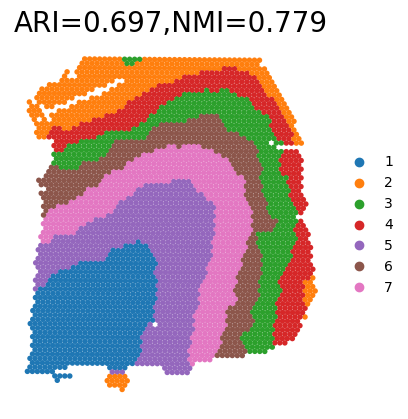

In [15]:
ARI_m = adjusted_rand_score(sub_adata.obs['mclust_labels'], sub_adata.obs['layer_guess'])
NMI = normalized_mutual_info_score(sub_adata.obs['mclust_labels'], sub_adata.obs['layer_guess'])
sc.pl.spatial(sub_adata, color=['mclust_labels'], title=['ARI=%.3f,NMI=%.3f'%(ARI_m,NMI)],img_key=None,
    frameon=False,spot_size=150)


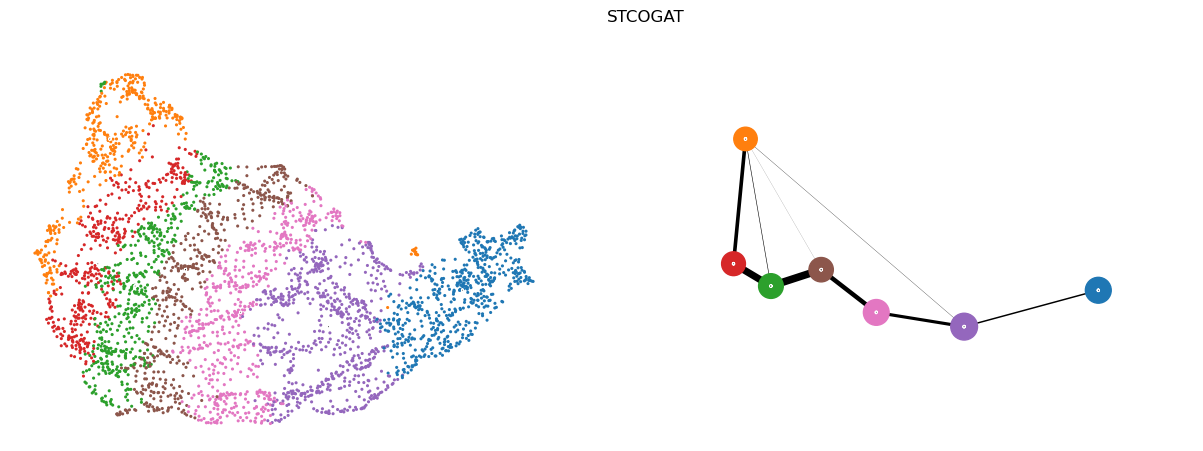

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

In [16]:
sc.pp.neighbors(recon_adata, use_rep='embed')
sc.tl.umap(sub_adata)
sc.tl.paga(sub_adata,groups='mclust_labels')
sc.pl.paga_compare(sub_adata, color="mclust_labels",random_state=1,
                             size = 20,legend_fontsize=0,  node_size_scale=2,
                             frameon=False, legend_fontoutline=2,title='STCOGAT',save='PAGA.pdf')